# M5 — KPI Anomaly Monitoring

**Goal.** Detect abnormal shifts in the line's KPIs *over time*, and — the core of
M5 — **quantify how well** the detector does it. The synthetic line gives us what
the real log cannot: **labeled, timestamped anomalies** to score against.

**Method (fixed by the owner; interpretable, no black boxes):**

1. **Inject known anomalies** via the CRN generator, each with a ground-truth
   window: (a) bottleneck **breakdown** (S4 loses a tool), (b) **demand surge**
   (extra arrivals), (c) gradual **degradation** (S4 slowly slows down). The draw
   table is never mutated, so each anomalous run has a CRN-paired clean twin and
   is identical to it before the anomaly starts (causality).
2. **Detect** with two simple statistics on daily KPI series: a **control chart**
   (center ± k·σ) for sudden shifts, and **EWMA** for slow drift. Baseline
   statistics are fit on clean pre-anomaly days only (no leakage).
3. **Score** detection quality: detection delay, lead time, false-alarm rate,
   precision/recall — and the **sensitivity trade-off** (too sensitive → false
   alarms; too blunt → slow detection).
4. **Honest limit:** the real 4TU log has no labeled anomalies, so on it we can
   only *show what gets flagged* — no precision/recall claims.

*Static matplotlib figures (GitHub-visible); synthetic data labeled synthetic;
anomalies are injected and labeled as such.*

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

ROOT = Path("..")
for p in ["src", "src/generator", "src/monitoring"]:
    sys.path.insert(0, str(ROOT / p))

from m5_config import m5_config
import anomalies as anom
import kpi_series as ks
import detectors as det
import evaluation as ev

FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

cfg = m5_config(horizon_days=160, warmup_days=6)
SCEN = anom.default_scenario(cfg)
WINDOWS = anom.scenario_windows(SCEN)
BASE_DAYS = list(range(10, 49))          # clean days before the first anomaly (day 55)
GRACE = anom.EVAL_GRACE_DAYS

WIN_COLORS = {"breakdown": "#EF9A9A", "demand_surge": "#FFCC80", "degradation": "#CE93D8"}

def shade_windows(ax):
    for w in WINDOWS:
        ax.axvspan(w["t_start"]/24, w["t_end"]/24, color=WIN_COLORS[w["type"]],
                   alpha=0.45, zorder=0)

pd.DataFrame(WINDOWS)

C:\Users\User\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,type,station,t_start,t_end,tools_removed,extra_rate,alpha
0,breakdown,S4,1320.0,1368.0,1.0,NaN,NaN
1,demand_surge,NaN,1968.0,2064.0,NaN,0.4,NaN
2,degradation,S4,2640.0,3240.0,NaN,NaN,0.00025


## Step 1 — Inject labeled anomalies (ground truth)

Three anomalies are injected on the 160-day M5 line (a longer horizon than M2-M4's
60 days, so there is room for a clean baseline and clean recovery gaps). Each run
is a **CRN-paired** clean twin + anomalous run on the same draw table. The overlay
below is the ground truth the detectors are scored against — the anomalous series
departs from the clean twin only inside/after each shaded window (before the first
window they are byte-identical; verified by `monitoring_check.py`).

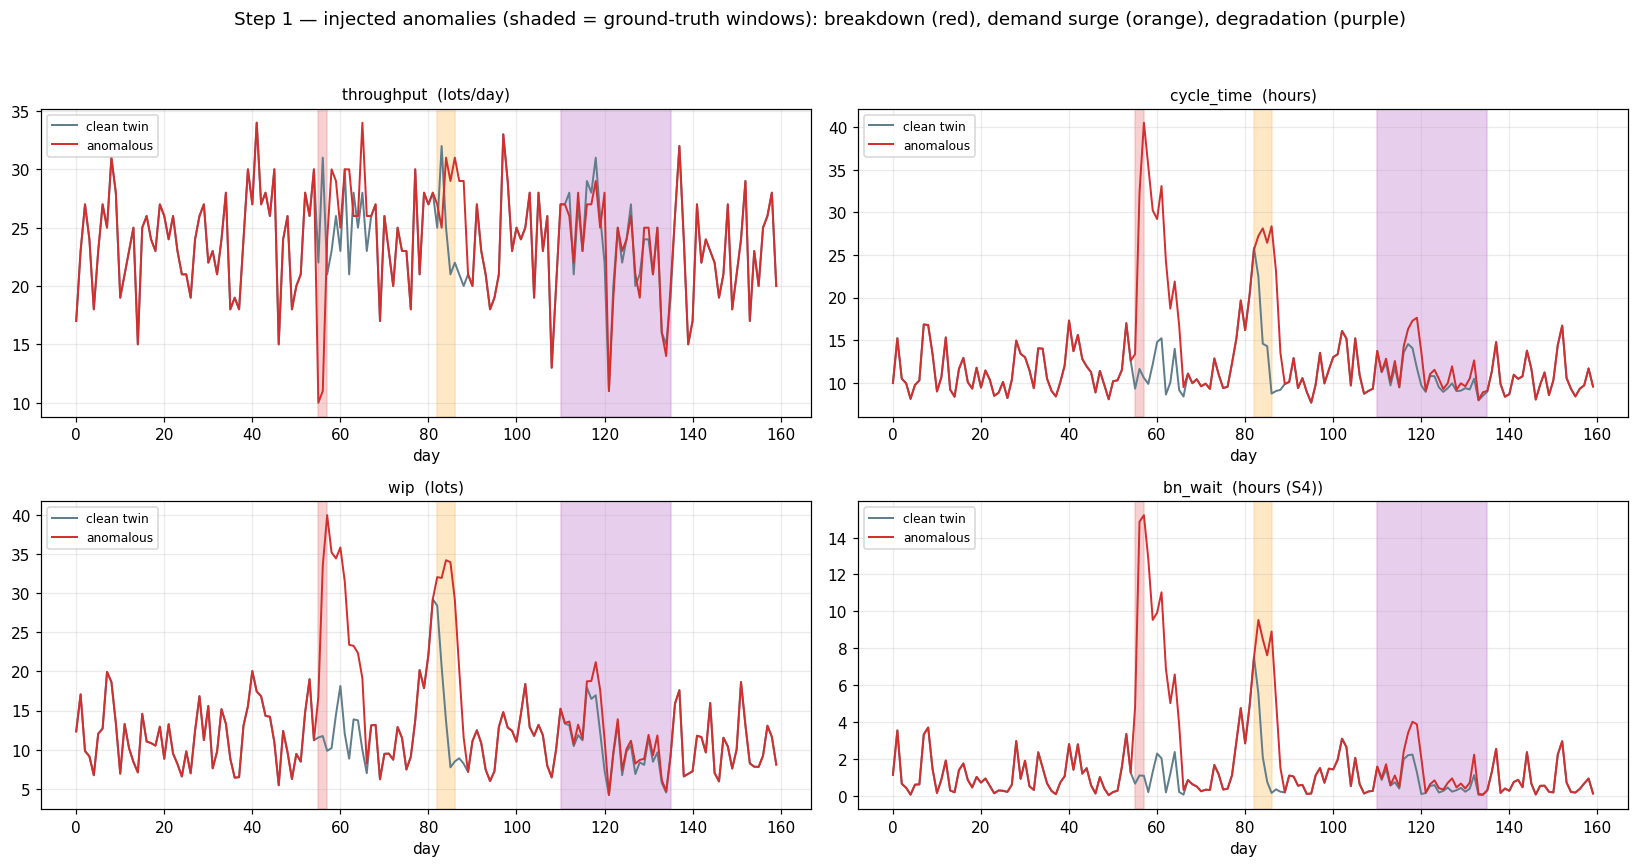

In [2]:
res0 = anom.run_clean_and_anomalous(cfg, seed=2000, anomalies=SCEN)
log_c0, life_c0, _ = res0["clean"]
log_a0, life_a0, _ = res0["anomalous"]
dc0 = ks.daily_kpis(log_c0, life_c0, cfg)
da0 = ks.daily_kpis(log_a0, life_a0, cfg)

panels = [("throughput","lots/day"),("cycle_time","hours"),
          ("wip","lots"),("bn_wait","hours (S4)")]
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax,(k,unit) in zip(axes.ravel(), panels):
    shade_windows(ax)
    ax.plot(dc0.index, dc0[k], color="#607D8B", lw=1.3, label="clean twin")
    ax.plot(da0.index, da0[k], color="#D32F2F", lw=1.3, label="anomalous")
    ax.set_title(f"{k}  ({unit})", fontsize=10); ax.set_xlabel("day")
    ax.grid(alpha=0.25); ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Step 1 — injected anomalies (shaded = ground-truth windows): "
             "breakdown (red), demand surge (orange), degradation (purple)", fontsize=12)
fig.tight_layout(rect=(0,0,1,0.95))
fig.savefig(FIG/"anomaly_injection_overview.png", bbox_inches="tight", dpi=150)
plt.show()

**Reading.** The breakdown produces a sharp spike (S4 half-capacity → backlog),
the surge a rising ramp (extra load accumulates), and the degradation a gentle
slow drift (S4 processing time creeping up while ρ stays near 1). Each has a very
different *time signature* — which is exactly why one detector is not enough.

## Step 2-3 — Detectors on the daily KPI series (leakage-free baseline)

We watch daily KPIs with two complementary detectors. **Baseline center/σ are fit
on clean pre-anomaly days only** (days 10-48, before the first anomaly at day 55),
so the detector never sees the anomaly it must catch.

- **Control chart** — alarm when a day leaves `center ± k·σ` (k=3). Fast on sudden
  shifts.
- **EWMA** — `z_t = λ·x_t + (1-λ)·z_{t-1}` with time-varying limits (λ=0.2). Reacts
  to small, *persistent* offsets — i.e. slow drift.

baseline (clean days 10-48): center=11.24  sigma=2.30


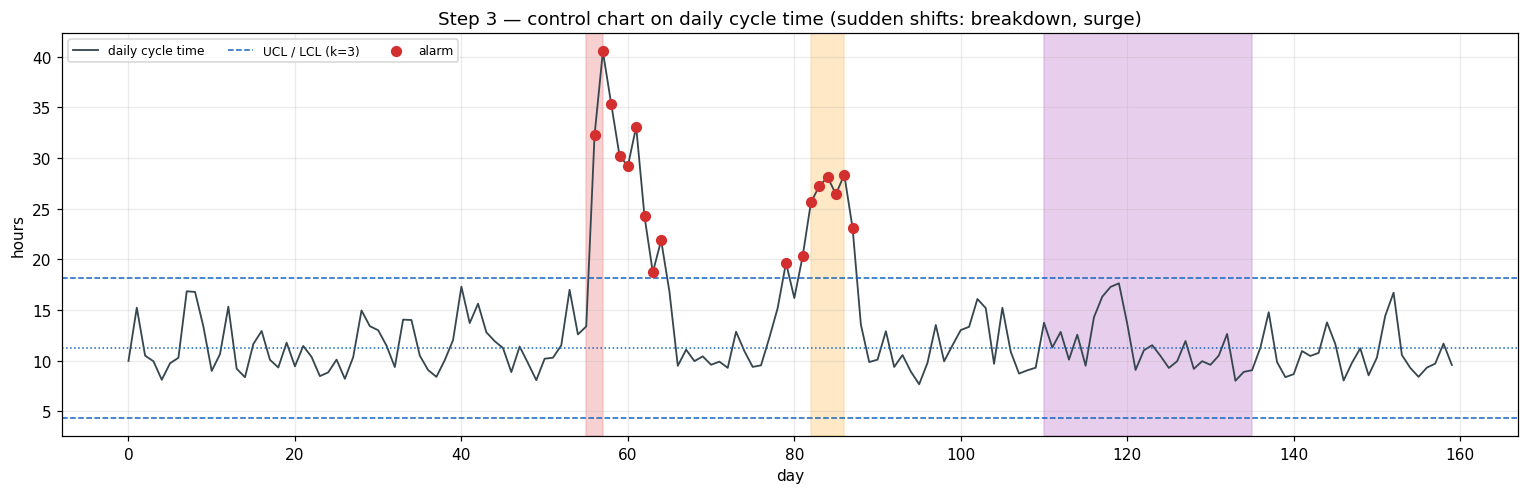

In [3]:
KPI = "cycle_time"
s0 = da0[KPI]
center, sigma = det.fit_baseline(s0, BASE_DAYS)
cc0 = det.control_chart(s0, center, sigma, k=3.0)
ew0 = det.ewma_chart(s0, center, sigma, lam=0.2, L=3.0)
print(f"baseline (clean days 10-48): center={center:.2f}  sigma={sigma:.2f}")

# Control chart figure
fig, ax = plt.subplots(figsize=(14, 4.6))
shade_windows(ax)
ax.plot(s0.index, s0.values, color="#37474F", lw=1.2, label="daily cycle time")
ax.axhline(cc0["ucl"].iloc[0], color="#1565C0", ls="--", lw=1, label="UCL / LCL (k=3)")
ax.axhline(cc0["lcl"].iloc[0], color="#1565C0", ls="--", lw=1)
ax.axhline(center, color="#1565C0", ls=":", lw=1)
al = cc0.index[cc0["alarm"]]
ax.scatter(al, s0.reindex(al), color="#D32F2F", s=40, zorder=5, label="alarm")
ax.set_title("Step 3 — control chart on daily cycle time (sudden shifts: breakdown, surge)")
ax.set_xlabel("day"); ax.set_ylabel("hours"); ax.grid(alpha=0.25); ax.legend(fontsize=8, ncol=4)
fig.tight_layout(); fig.savefig(FIG/"detector_control_chart.png", bbox_inches="tight", dpi=150)
plt.show()

The control chart flags the breakdown and the demand surge quickly (their KPI
excursions blow past 3σ). But the **gradual degradation** raises the mean only
slowly — individual days often stay within ±3σ, so the Shewhart chart is late or
silent. That is where EWMA earns its place:

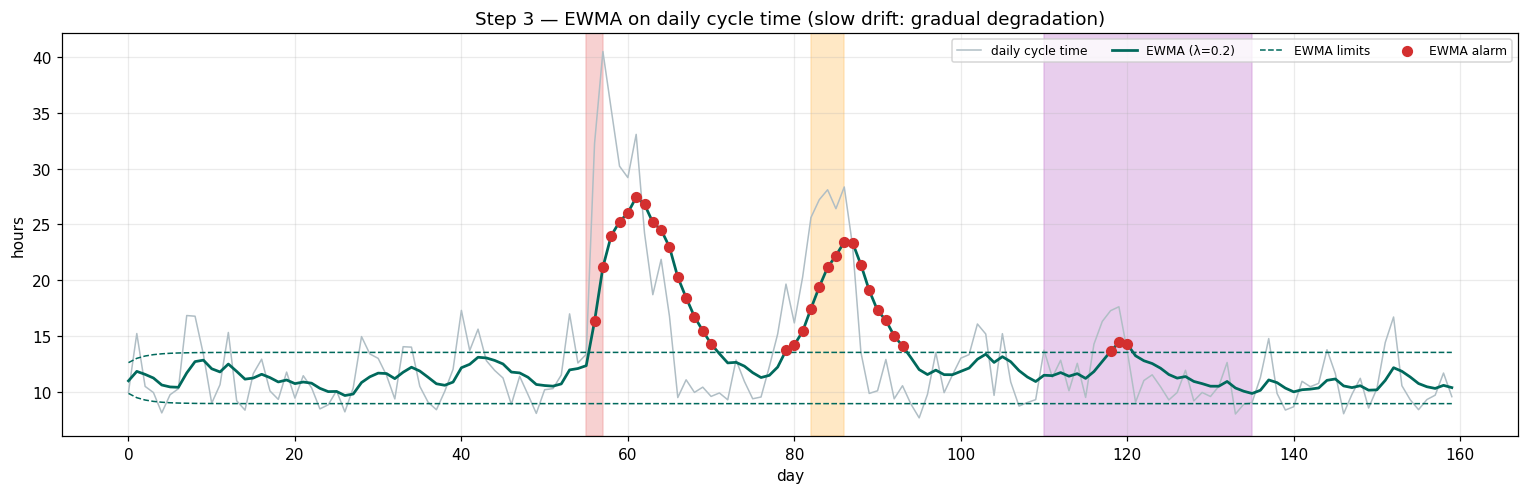

degradation — control chart: {'detected': False, 'delay_days': None}
degradation — EWMA        : {'detected': True, 'delay_days': 8}


In [4]:
# EWMA figure, with control-chart alarms overlaid to show the drift gap
fig, ax = plt.subplots(figsize=(14, 4.6))
shade_windows(ax)
ax.plot(ew0.index, ew0["value"], color="#B0BEC5", lw=1.0, label="daily cycle time")
ax.plot(ew0.index, ew0["ewma"], color="#00695C", lw=1.8, label="EWMA (λ=0.2)")
ax.plot(ew0.index, ew0["ucl"], color="#00695C", ls="--", lw=1, label="EWMA limits")
ax.plot(ew0.index, ew0["lcl"], color="#00695C", ls="--", lw=1)
ew_al = ew0.index[ew0["alarm"]]
ax.scatter(ew_al, ew0["ewma"].reindex(ew_al), color="#D32F2F", s=40, zorder=5, label="EWMA alarm")
ax.set_title("Step 3 — EWMA on daily cycle time (slow drift: gradual degradation)")
ax.set_xlabel("day"); ax.set_ylabel("hours"); ax.grid(alpha=0.25); ax.legend(fontsize=8, ncol=5)
fig.tight_layout(); fig.savefig(FIG/"detector_ewma.png", bbox_inches="tight", dpi=150)
plt.show()

cc_deg = ev.evaluate_single(cc0, WINDOWS, s0, BASE_DAYS)["per_anomaly"][2]
ew_deg = ev.evaluate_single(ew0, WINDOWS, s0, BASE_DAYS)["per_anomaly"][2]
print("degradation — control chart:", {k:cc_deg[k] for k in ["detected","delay_days"]})
print("degradation — EWMA        :", {k:ew_deg[k] for k in ["detected","delay_days"]})

## Step 4 — Detection quality (the core of M5)

Because the anomalies are labeled, we score the detectors across **12 replications**
(36 injected anomalies) and on genuinely clean, held-out days.

**Definitions (stated so they are not circular):**
- **detection delay** = first in-window alarm − the anomaly's **injection time**
  (the cleanest ground truth).
- **lead time** = the first alarm − the day the *actual* KPI first crosses an
  **independent physical threshold** (normal clean-baseline median × 1.5). This
  threshold is defined from actual KPI values vs the normal operating level and
  **never** from the detector's own σ — otherwise the detector would be measured
  against itself. Positive lead = warned before the KPI became physically obvious;
  for *sudden* anomalies the impact is immediate, so lead is ≈0 or negative and
  detection delay is the meaningful metric.
- **false-alarm rate** = alarms on held-out clean days / clean days (baseline and
  warm-up excluded).

In [5]:
N = 12
runs = []
for i in range(N):
    r = anom.run_clean_and_anomalous(cfg, seed=2000+i, anomalies=SCEN)
    la, lifea, _ = r["anomalous"]
    runs.append((ks.daily_kpis(la, lifea, cfg), r["windows"]))

def score(kpi, detector, **kw):
    singles = []
    for da, windows in runs:
        s = da[kpi]; c, sg = det.fit_baseline(s, BASE_DAYS)
        d = detector(s, c, sg, **kw)
        singles.append(ev.evaluate_single(d, windows, s, BASE_DAYS))
    return singles, ev.aggregate(singles)

cc_singles, cc_agg = score("cycle_time", det.control_chart, k=3.0)
ew_singles, ew_agg = score("cycle_time", det.ewma_chart, lam=0.2, L=3.0)
summary = pd.DataFrame({"control chart (k=3)": cc_agg, "EWMA (λ=0.2)": ew_agg}).T
display(summary[["recall","precision","false_alarm_rate",
                 "mean_detection_delay_days","mean_lead_days"]].round(3))

# detection rate per anomaly type
def per_type_rate(singles):
    t = ev.per_anomaly_table(singles)
    return t.groupby("type")["detected"].mean()
rates = pd.DataFrame({"control chart": per_type_rate(cc_singles),
                      "EWMA": per_type_rate(ew_singles)}).round(2)
print("Detection rate by anomaly type (fraction detected across 12 reps):")
display(rates)

,recall,precision,false_alarm_rate,mean_detection_delay_days,mean_lead_days
control chart (k=3),0.778,0.862,0.057,3.821,-0.786
EWMA (λ=0.2),0.806,0.825,0.148,4.000,-0.828


Detection rate by anomaly type (fraction detected across 12 reps):


,control chart,EWMA
type,,
breakdown,0.83,0.83
degradation,0.67,0.75
demand_surge,0.83,0.83


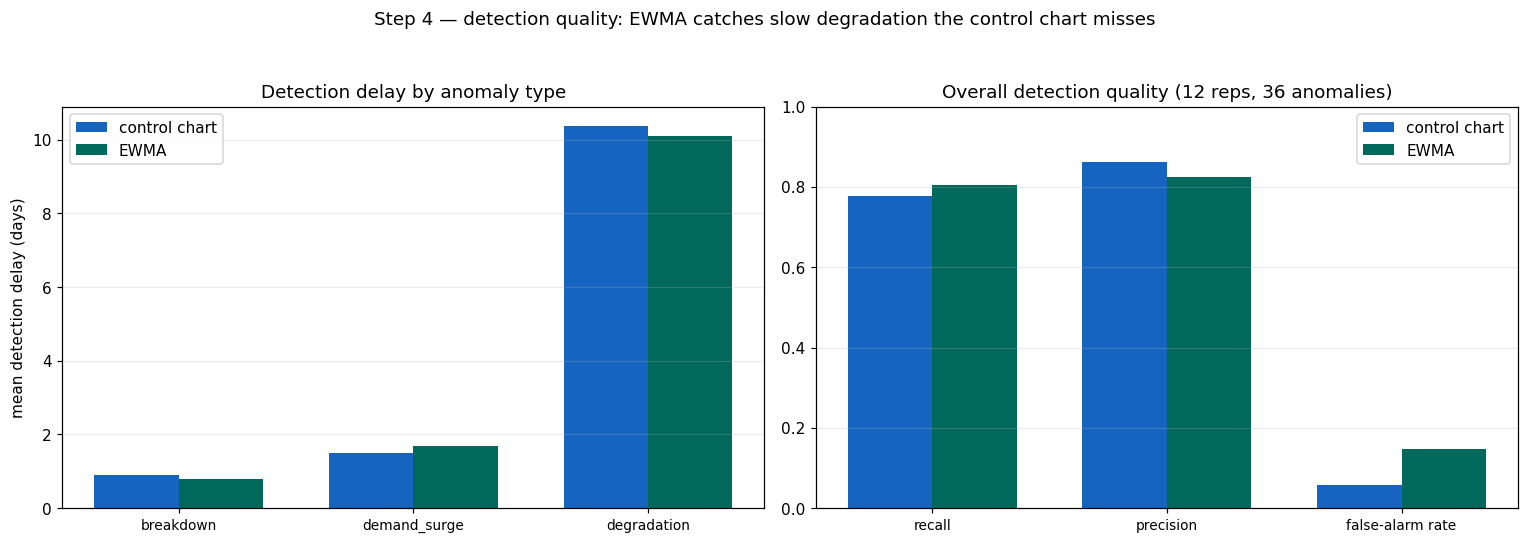

In [6]:
# Figure: detection quality
cc_t = ev.per_anomaly_table(cc_singles); ew_t = ev.per_anomaly_table(ew_singles)
types = ["breakdown","demand_surge","degradation"]
cc_delay = [cc_t[(cc_t.type==ty)]["delay_days"].dropna().mean() for ty in types]
ew_delay = [ew_t[(ew_t.type==ty)]["delay_days"].dropna().mean() for ty in types]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(types)); w = 0.36
axes[0].bar(x-w/2, cc_delay, w, color="#1565C0", label="control chart")
axes[0].bar(x+w/2, ew_delay, w, color="#00695C", label="EWMA")
axes[0].set_xticks(x); axes[0].set_xticklabels(types, fontsize=9)
axes[0].set_ylabel("mean detection delay (days)")
axes[0].set_title("Detection delay by anomaly type"); axes[0].legend(); axes[0].grid(axis="y", alpha=0.25)

mets = ["recall","precision","false_alarm_rate"]
cc_v = [cc_agg[m] for m in mets]; ew_v = [ew_agg[m] for m in mets]
x2 = np.arange(len(mets))
axes[1].bar(x2-w/2, cc_v, w, color="#1565C0", label="control chart")
axes[1].bar(x2+w/2, ew_v, w, color="#00695C", label="EWMA")
axes[1].set_xticks(x2); axes[1].set_xticklabels(["recall","precision","false-alarm rate"], fontsize=9)
axes[1].set_ylim(0,1); axes[1].set_title("Overall detection quality (12 reps, 36 anomalies)")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.25)
fig.suptitle("Step 4 — detection quality: EWMA catches slow degradation the control chart misses", fontsize=12)
fig.tight_layout(rect=(0,0,1,0.94))
fig.savefig(FIG/"detection_quality.png", bbox_inches="tight", dpi=150)
plt.show()

**Reading.** Both detectors catch the sudden breakdown and surge within a day or
two. The **control chart largely misses the slow degradation** while **EWMA catches
it** — the complementarity that justifies running both. Lead time is ≈0/negative for
the sudden anomalies (their impact is immediate) and is where EWMA's early drift
warning matters.

### Sensitivity trade-off

There is no free lunch: making a detector more sensitive (smaller `k`, or an EWMA
`λ` with tighter limits) lowers detection delay but raises the false-alarm rate —
and operators stop trusting a monitor that cries wolf. Too blunt, and detection is
slow. We sweep both knobs:

control-chart k sweep:


,param,recall,precision,false_alarm_rate,mean_detection_delay_days
0,2.0,0.889,0.806,0.106,3.188
1,2.5,0.833,0.837,0.078,3.900
2,3.0,0.778,0.862,0.057,3.821
3,3.5,0.778,0.861,0.052,4.179
4,4.0,0.778,0.888,0.037,4.714


EWMA λ sweep:


,param,recall,precision,false_alarm_rate,mean_detection_delay_days
0,0.1,0.833,0.681,0.417,2.900
1,0.2,0.806,0.825,0.148,4.000
2,0.3,0.806,0.850,0.102,3.966
3,0.5,0.833,0.841,0.087,4.133


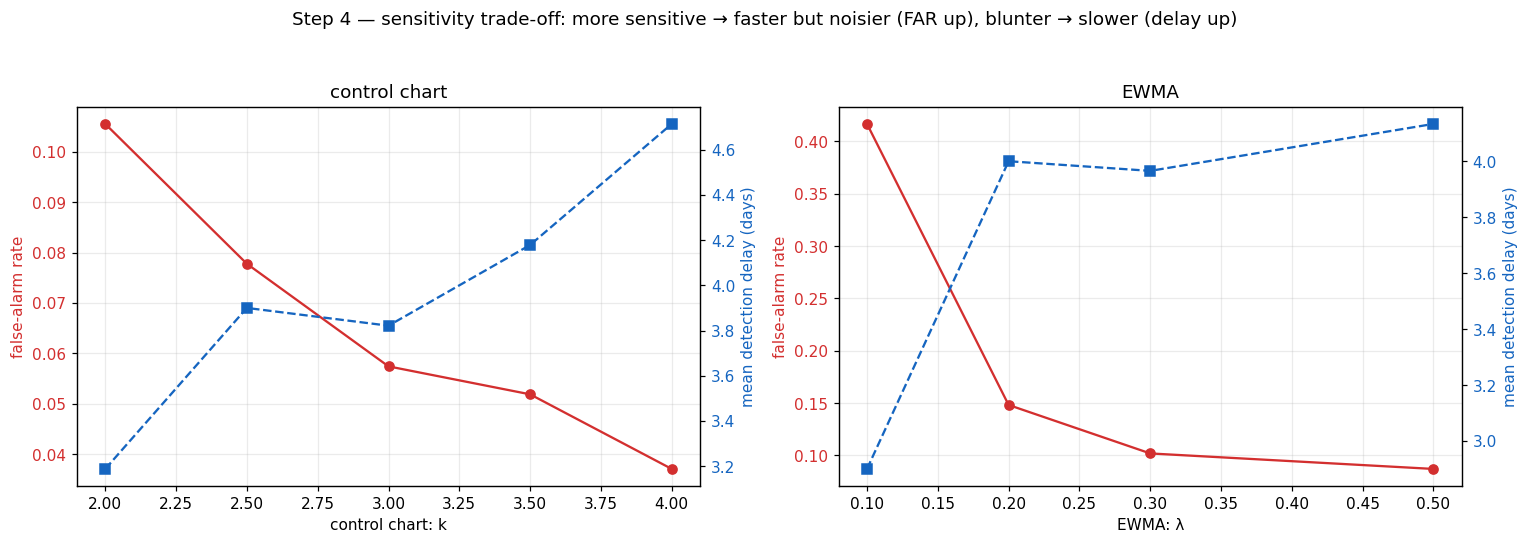

In [7]:
series_list = [da["cycle_time"] for da,_ in runs]
base_list = [BASE_DAYS]*len(runs); win_list = [w for _,w in runs]
sweep_k = ev.sensitivity_sweep(series_list, base_list, win_list, det.control_chart,
                               [2.0,2.5,3.0,3.5,4.0], "k")
sweep_l = ev.sensitivity_sweep(series_list, base_list, win_list, det.ewma_chart,
                               [0.1,0.2,0.3,0.5], "lam")
print("control-chart k sweep:"); display(sweep_k.round(3))
print("EWMA λ sweep:"); display(sweep_l.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sw, name in [(axes[0], sweep_k, "control chart: k"),
                     (axes[1], sweep_l, "EWMA: λ")]:
    ax.plot(sw["param"], sw["false_alarm_rate"], "o-", color="#D32F2F", label="false-alarm rate")
    ax.set_xlabel(name); ax.set_ylabel("false-alarm rate", color="#D32F2F")
    ax.tick_params(axis="y", labelcolor="#D32F2F"); ax.grid(alpha=0.25)
    ax2 = ax.twinx()
    ax2.plot(sw["param"], sw["mean_detection_delay_days"], "s--", color="#1565C0",
             label="detection delay")
    ax2.set_ylabel("mean detection delay (days)", color="#1565C0")
    ax2.tick_params(axis="y", labelcolor="#1565C0")
    ax.set_title(name.split(':')[0])
fig.suptitle("Step 4 — sensitivity trade-off: more sensitive → faster but noisier "
             "(FAR up), blunter → slower (delay up)", fontsize=12)
fig.tight_layout(rect=(0,0,1,0.94))
fig.savefig(FIG/"sensitivity_tradeoff.png", bbox_inches="tight", dpi=150)
plt.show()

## Step 5 — Apply to the real 4TU log (flags only, no ground truth)

We build a daily KPI series from the real log and run the same detectors. **The real
log has no labeled anomalies**, so we can *show which days get flagged* but **cannot**
compute detection delay, precision, or recall — there is nothing to score against.
This limit is stated here and on the figure.

We use **daily mean inter-step waiting time per D-event** (a congestion KPI aligned
with bottleneck monitoring: the gap between a step's start and the previous step's
completion within a case, as in notebook 01). It is variable enough for a daily
chart; the baseline is fit on an early stretch.

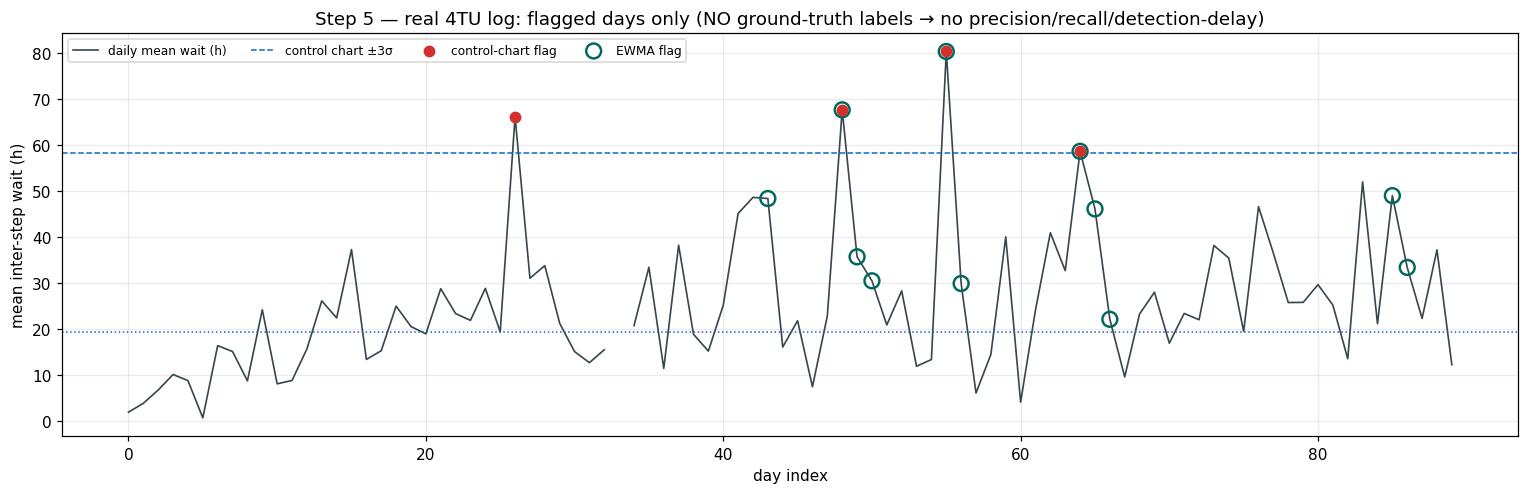

baseline center=19.5h sigma=12.9h | control-chart flags: 4 days | EWMA flags: 11 days
These are candidate abnormal days only — no labeled anomalies exist to score against.


In [8]:
raw = pd.read_csv(ROOT/"data"/"raw"/"Production_Data.csv")
raw.columns = raw.columns.str.strip()
for c in ["Start Timestamp","Complete Timestamp"]:
    raw[c] = pd.to_datetime(raw[c], format="%Y/%m/%d %H:%M:%S.%f")
dfD = raw[raw["Report Type"]=="D"].sort_values(["Case ID","Start Timestamp"]).reset_index(drop=True)
dfD["prev_complete"] = dfD.groupby("Case ID")["Complete Timestamp"].shift(1)
dfD["waiting_h"] = ((dfD["Start Timestamp"] - dfD["prev_complete"]).dt.total_seconds()/3600).clip(lower=0)
dfD["day"] = dfD["Complete Timestamp"].dt.normalize()

daily = dfD.groupby("day")["waiting_h"].mean()
daily.index = (daily.index - daily.index.min()).days          # day index from 0
real_s = daily.reindex(range(int(daily.index.min()), int(daily.index.max())+1))  # NaN on gap days

rbase = list(real_s.dropna().index[:30])                      # first ~30 observed days
rc, rsg = det.fit_baseline(real_s, rbase)
rcc = det.control_chart(real_s, rc, rsg, k=3.0)
rew = det.ewma_chart(real_s, rc, rsg, lam=0.2, L=3.0)

fig, ax = plt.subplots(figsize=(14, 4.6))
ax.plot(real_s.index, real_s.values, color="#37474F", lw=1.1, label="daily mean wait (h)")
ax.axhline(rcc["ucl"].iloc[0], color="#1565C0", ls="--", lw=1, label="control chart ±3σ")
ax.axhline(rc, color="#1565C0", ls=":", lw=1)
ax.scatter(rcc.index[rcc["alarm"]], real_s.reindex(rcc.index[rcc["alarm"]]),
           color="#D32F2F", s=45, zorder=5, label="control-chart flag")
ax.scatter(rew.index[rew["alarm"]], real_s.reindex(rew.index[rew["alarm"]]),
           facecolors="none", edgecolors="#00695C", s=95, lw=1.6, zorder=4, label="EWMA flag")
ax.set_title("Step 5 — real 4TU log: flagged days only (NO ground-truth labels → "
             "no precision/recall/detection-delay)")
ax.set_xlabel("day index"); ax.set_ylabel("mean inter-step wait (h)"); ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=4)
fig.tight_layout(); fig.savefig(FIG/"real_log_flags.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"baseline center={rc:.1f}h sigma={rsg:.1f}h | "
      f"control-chart flags: {int(rcc['alarm'].sum())} days | EWMA flags: {int(rew['alarm'].sum())} days")
print("These are candidate abnormal days only — no labeled anomalies exist to score against.")

## Summary

| Step | Output |
|---|---|
| 1 Injection | 3 labeled anomalies (breakdown, surge, degradation) via CRN generator; anomalous run == clean twin before each window (causality) |
| 2-3 Detectors | control chart (sudden) + EWMA (drift), baseline fit on clean pre-anomaly days only (leakage-free) |
| 4 Quality | 12 reps / 36 anomalies: control chart fast on sudden shocks but misses slow drift; EWMA catches the degradation; FAR ≈0.05-0.07 (k=3); sensitivity trade-off quantified |
| 5 Real log | same detectors flag candidate abnormal days — **no ground truth, so no quality metrics** |

**Figures (`reports/figures/`):** `anomaly_injection_overview.png`,
`detector_control_chart.png`, `detector_ewma.png`, `detection_quality.png`,
`sensitivity_tradeoff.png`, `real_log_flags.png`.

**Method integrity:** detectors are transparent control-chart / EWMA statistics (no
black box); baselines use only clean pre-anomaly data (no leakage); the lead-time
threshold is a physical operating-level rule independent of the detector; on real
data we flag only and make no detection-quality claims.